In [3]:
import pandas as pd

# Load the raw training data
df = pd.read_csv('/Users/nathmensah/Desktop/gitcolab/ACSES_hackathon_2026/flood-risk-prediction-platform-/ml_models/data/raw/train.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum(), "total nulls")
print("\nTarget variable summary:")
print(df['FloodProbability'].describe())

df.head()

Shape: (1117957, 22)

Column dtypes:
 id                                   int64
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments                        int64
IneffectiveDisasterPreparedness      int64
DrainageSystems                      int64
CoastalVulnerability                 int64
Landslides                           int64
Watersheds                           int64
DeterioratingInfrastructure          int64
PopulationScore                      int64
WetlandLoss                          int64
InadequatePlanning                   int64
PoliticalFactors                     int64
FloodProbability                   float64
dtype: object

M

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [4]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['id', 'FloodProbability'])
y = df['FloodProbability']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (894365, 20)
X_test shape: (223592, 20)


In [6]:
from xgboost import XGBRegressor
import time

# Initialize XGBoost regressor with sensible baseline defaults
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

start = time.time()
model.fit(X_train, y_train)
print(f"Training completed in {time.time() - start:.1f} seconds")

Training completed in 25.6 seconds


In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Generate predictions on the held-out test set
y_pred = model.predict(X_test)

# Compute regression metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.5f}")
print(f"R² Score: {r2:.5f}")

RMSE: 0.02084
R² Score: 0.83290


In [11]:
import joblib
import os

# Path relative to the notebook's location (ml_models/notebooks/)
# '..' goes up to ml_models/, then into artifacts/
artifacts_dir = '../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

model_path = os.path.join(artifacts_dir, 'flood_risk_xgb_baseline.joblib')
joblib.dump(model, model_path)

print(f"Model saved to: {os.path.abspath(model_path)}")

Model saved to: /Users/nathmensah/Desktop/gitcolab/ACSES_hackathon_2026/flood-risk-prediction-platform-/ml_models/artifacts/flood_risk_xgb_baseline.joblib


<Figure size 1000x800 with 0 Axes>

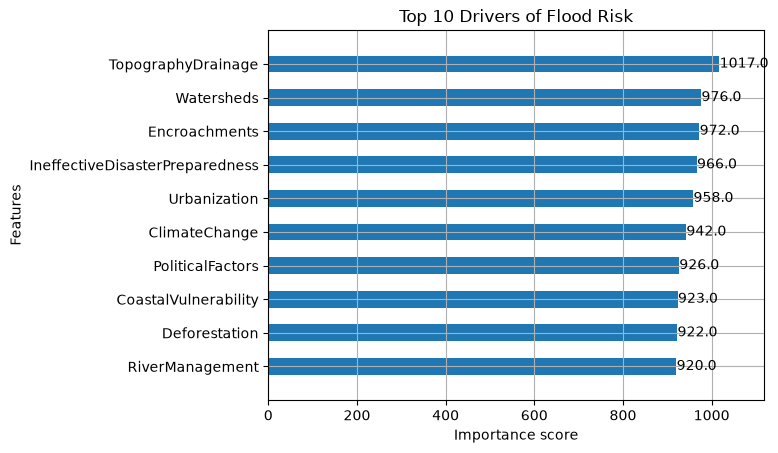

In [12]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=10, importance_type='weight', height=0.5)
plt.title('Top 10 Drivers of Flood Risk')
plt.show()